In [81]:
# import necessary libraries
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [82]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plotting style
sns.set_theme(style="whitegrid")

In [83]:
# Download the dataset from Kaggle and save it to the current directory
path = kagglehub.dataset_download(
    "datascikhan/e-commerce-sales-and-customer-analytics",
    path="ecommerce_sales_customer_analytics_150k.csv",
    output_dir="."
)

print("Path to dataset file:", path)

Using Colab cache for faster access to the 'e-commerce-sales-and-customer-analytics' dataset.
Path to dataset file: /kaggle/input/e-commerce-sales-and-customer-analytics/ecommerce_sales_customer_analytics_150k.csv


In [84]:
df = pd.read_csv(path)

In [85]:
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [86]:
# DATA CLEANING

# Keep original data unchanged
df_raw = df.copy()

# Create working copy for cleaning
df_clean = df.copy()

print("Raw dataset shape:", df_raw.shape)
print("Working dataset shape:", df_clean.shape)

Raw dataset shape: (138116, 46)
Working dataset shape: (138116, 46)


In [87]:
# DUPLICATE CHECK

print("Complete duplicate rows:", df_clean.duplicated().sum())

print("Duplicate order IDs:", df_clean["order_id"].duplicated().sum())

print("Unique order IDs:", df_clean["order_id"].nunique())

print("Total rows:", len(df_clean))

Complete duplicate rows: 0
Duplicate order IDs: 0
Unique order IDs: 138116
Total rows: 138116


In [88]:
print("\nColumn names:")
print(df_clean.columns.tolist())


Column names:
['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel', 'customer_id', 'customer_name', 'customer_age', 'gender', 'customer_segment', 'customer_type', 'customer_city', 'customer_state', 'customer_country', 'region', 'customer_postal_code', 'payment_method', 'payment_status', 'currency', 'shipping_method', 'warehouse', 'delivery_days', 'estimated_delivery_days', 'delivery_status', 'return_status', 'return_reason', 'customer_rating', 'review_sentiment', 'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code', 'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity', 'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost', 'profit', 'profit_margin_percentage', 'customer_lifetime_value', 'is_repeat_customer', 'customer_order_count']


In [89]:
print("\nData types:")
print(df_clean.dtypes)


Data types:
order_id                     object
order_date                   object
order_time                   object
order_status                 object
sales_channel                object
customer_id                  object
customer_name                object
customer_age                  int64
gender                       object
customer_segment             object
customer_type                object
customer_city                object
customer_state               object
customer_country             object
region                       object
customer_postal_code          int64
payment_method               object
payment_status               object
currency                     object
shipping_method              object
warehouse                    object
delivery_days               float64
estimated_delivery_days     float64
delivery_status              object
return_status                object
return_reason                object
customer_rating             float64
review_sentimen

In [90]:
print("\nDataFrame info:")
df_clean.info()


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  object 
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  object 
 4   sales_channel             138116 non-null  object 
 5   customer_id               138116 non-null  object 
 6   customer_name             138116 non-null  object 
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  object 
 9   customer_segment          138116 non-null  object 
 10  customer_type             138116 non-null  object 
 11  customer_city             138116 non-null  object 
 12  customer_state            138116 non-null  object 
 13  customer_country          1

In [91]:
print("\nFirst 5 rows of the DataFrame:")
df_clean.head(5)


First 5 rows of the DataFrame:


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.00,3.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,"1,350.19",477.89,61.07,12.03,945.40,588.33,345.04,36.50,"12,459.68",True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.00,10.00,On Time,NaN,NaN,3.60,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,"3,144.64","1,456.06",320.83,9.00,"2,018.41","2,031.88",-22.47,-1.11,"13,032.48",True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.00,3.00,On Time,NaN,NaN,4.30,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,"6,159.44",True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,USA,South,66329,Debit Card,Paid,USD,Express,WH-010,2.00,2.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Email Marketing,NaN,NaN,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,"5,638.30",True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,India,West,77306,Digital Wallet,Paid,INR,Standard,WH-013,6.00,5.00,Delayed,NaN,NaN,3.00,Neutral,Mixed feelings about this purchase.,Direct,NaN,NaN,278,147,6,"2,474.52",133.63,421.35,23.03,"2,785.27","1,231.88","1,530.36",54.94,"13,240.10",True,8


In [92]:
print("\nFeature summary:")
feature_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing Values": df_clean.isnull().sum().values,
    "Missing %": (df_clean.isnull().mean() * 100).round(2).values,
    "Unique Values": df_clean.nunique().values
})

feature_summary


Feature summary:


,Column,Missing Values,Missing %,Unique Values
0,order_id,0,0.00,138116
1,order_date,0,0.00,1826
2,order_time,0,0.00,68991
3,order_status,0,0.00,4
4,sales_channel,0,0.00,4
5,customer_id,0,0.00,24911
6,customer_name,0,0.00,21564
7,customer_age,0,0.00,57
8,gender,0,0.00,3
9,customer_segment,0,0.00,4


In [93]:
# MISSING VALUE ANALYSIS

missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]

print("Columns containing missing values:")
display(missing.sort_values("Missing Count", ascending=False))

Columns containing missing values:


,Missing Count,Missing Percentage
return_status,128654,93.15
return_reason,128654,93.15
coupon_code,110502,80.01
campaign_name,83233,60.26
delivery_days,24557,17.78
customer_rating,24557,17.78
estimated_delivery_days,24557,17.78
customer_review,24557,17.78
review_sentiment,24557,17.78


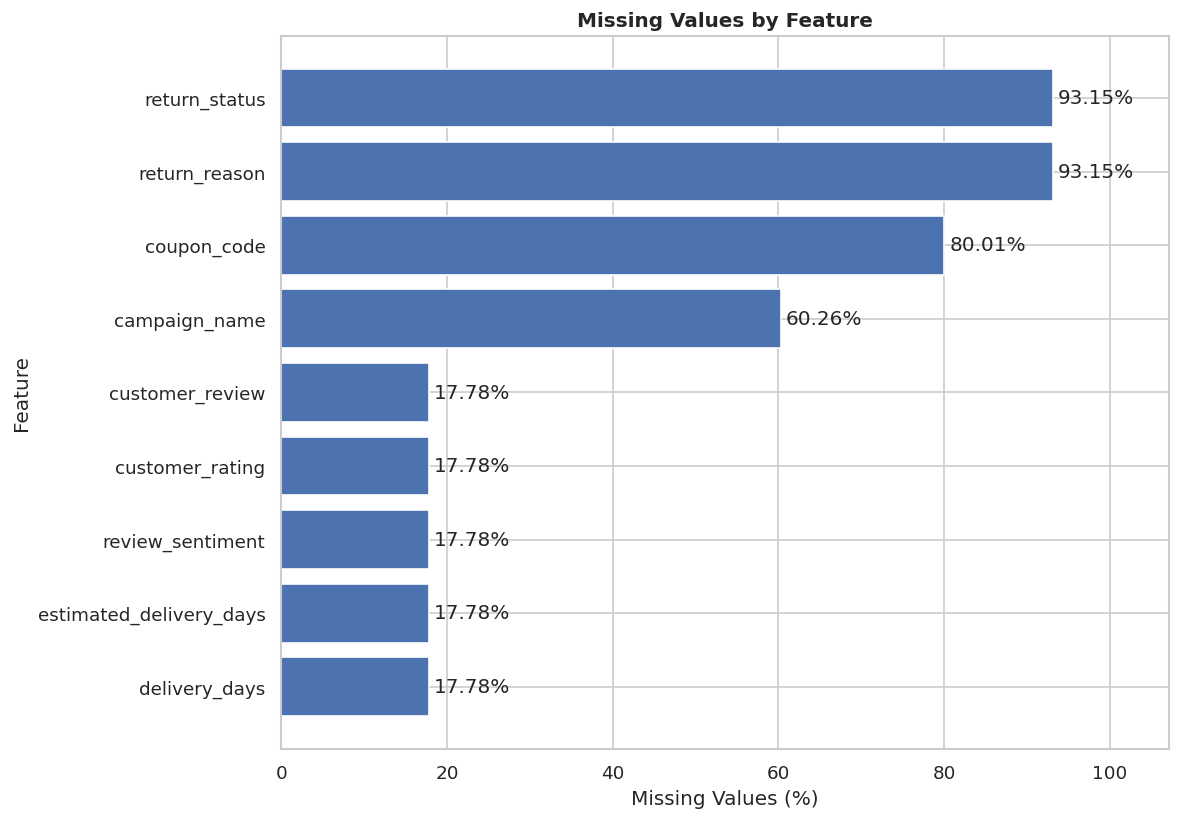

In [94]:
# MISSING VALUE VISUALIZATION

missing_sorted = missing.sort_values(
    "Missing Percentage",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    missing_sorted.index,
    missing_sorted["Missing Percentage"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")
ax.set_title("Missing Values by Feature")

ax.set_xlim(0, missing_sorted["Missing Percentage"].max() * 1.15)

plt.tight_layout()
plt.show()

In [95]:
# HANDLE STRUCTURAL MISSING VALUES

# Return-related fields
df_clean["return_status"] = df_clean["return_status"].fillna(
    "Not Returned"
)

df_clean["return_reason"] = df_clean["return_reason"].fillna(
    "Not Returned"
)

# Marketing fields
df_clean["campaign_name"] = df_clean["campaign_name"].fillna(
    "No Campaign"
)

df_clean["coupon_code"] = df_clean["coupon_code"].fillna(
    "No Coupon"
)

# Review fields
df_clean["review_sentiment"] = df_clean["review_sentiment"].fillna(
    "No Review"
)

df_clean["customer_review"] = df_clean["customer_review"].fillna(
    "No Review"
)

print(
    df_clean[["return_status", "return_reason", "campaign_name",
            "coupon_code", "review_sentiment", "customer_review"
        ]].isna().sum()
)

return_status       0
return_reason       0
campaign_name       0
coupon_code         0
review_sentiment    0
customer_review     0
dtype: int64


In [96]:
# ============================================================
# INVESTIGATE MISSING DELIVERY INFORMATION
# ============================================================

delivery_missing = df_clean[df_clean["delivery_days"].isna()]

print("Rows missing delivery days:", len(delivery_missing))

print("\nDelivery status for rows with missing delivery days:")
print(delivery_missing["delivery_status"].value_counts(dropna=False))

Rows missing delivery days: 24557

Delivery status for rows with missing delivery days:
delivery_status
Cancelled    24557
Name: count, dtype: int64


In [97]:
# Keep delivery_days and estimated_delivery_days as NaN
# because cancelled orders never had a delivery.

print(
    df_clean.loc[df_clean["delivery_days"].isna(), "delivery_status"]
    .value_counts(dropna=False)
)

delivery_status
Cancelled    24557
Name: count, dtype: int64


In [98]:
# ============================================================
# CUSTOMER RATING / REVIEW ANALYSIS
# ============================================================

rating_missing = df_clean["customer_rating"].isna()

print("Missing ratings:", rating_missing.sum())

print("\nReview status among missing ratings:")
print(
    df_clean.loc[
        rating_missing,
        "review_sentiment"
    ].value_counts(dropna=False)
)

Missing ratings: 24557

Review status among missing ratings:
review_sentiment
No Review    24557
Name: count, dtype: int64


In [99]:
# Keep customer_rating as NaN
# because "no rating" is different from a rating of 0.

print(
    df_clean.loc[df_clean["customer_rating"].isna(), "review_sentiment"]
    .value_counts(dropna=False)
)

review_sentiment
No Review    24557
Name: count, dtype: int64


In [100]:
# DATE AND TIME CLEANING

df_clean["order_datetime"] = pd.to_datetime(
    df_clean["order_date"].astype(str)
    + " "
    + df_clean["order_time"].astype(str),
    errors="coerce"
)

print(
    "Unparsed order_datetime values:",
    df_clean["order_datetime"].isna().sum()
)

Unparsed order_datetime values: 0


In [101]:
# TIME-BASED FEATURES

df_clean["order_date"] = df_clean["order_datetime"].dt.normalize()

df_clean["order_year"] = (
    df_clean["order_datetime"].dt.year
)

df_clean["order_month"] = (
    df_clean["order_datetime"].dt.month
)

df_clean["order_month_name"] = (
    df_clean["order_datetime"].dt.month_name()
)

df_clean["order_day"] = (
    df_clean["order_datetime"].dt.day
)

df_clean["order_quarter"] = (
    df_clean["order_datetime"].dt.quarter
)

df_clean["order_hour"] = (
    df_clean["order_datetime"].dt.hour
)

df_clean["order_weekday"] = (
    df_clean["order_datetime"].dt.day_name()
)

df_clean["is_weekend"] = (
    df_clean["order_datetime"].dt.dayofweek >= 5
)

In [102]:
df_clean[
    ["order_datetime", "order_year", "order_month", "order_day",
     "order_month_name", "order_quarter", "order_hour", "order_weekday", "is_weekend"]
].head()

,order_datetime,order_year,order_month,order_day,order_month_name,order_quarter,order_hour,order_weekday,is_weekend
0,2023-11-06 16:37:47,2023,11,6,November,4,16,Monday,False
1,2025-12-24 01:22:36,2025,12,24,December,4,1,Wednesday,False
2,2021-07-05 14:24:21,2021,7,5,July,3,14,Monday,False
3,2023-01-21 07:20:26,2023,1,21,January,1,7,Saturday,True
4,2022-05-13 09:46:21,2022,5,13,May,2,9,Friday,False


In [103]:
# CHECK DATE RANGE FOR LATER ANALYSIS

print("Minimum order date:",
      df_clean["order_datetime"].min())

print("Maximum order date:",
      df_clean["order_datetime"].max())

Minimum order date: 2021-01-01 00:01:30
Maximum order date: 2025-12-31 23:58:53


In [104]:
# CHECK CUSTOMER AGE IF REASONABLE

print("Minimum age:",
      df_clean["customer_age"].min())

print("Maximum age:",
      df_clean["customer_age"].max())

Minimum age: 18
Maximum age: 74


Why the cleaning decisions are appropriate
The missing values are mostly structural rather than random errors. Cancelled orders do not have delivery times, ratings, or reviews, so those values remain missing. Return, campaign, coupon, and review text fields were filled with labels such as Not Returned, No Campaign, No Coupon, and No Review. These labels preserve the meaning of the missingness instead of incorrectly replacing it with zero or an average.
The separate order_datetime column combines the date and time into one true datetime field. From it, year, month, quarter, hour, weekday, and weekend indicators are created so that orders can be analyzed by time.

In [105]:
# done with cleaning the dataset
# part 1 checking
summary = pd.DataFrame({
    'Metric': ['Rows', 'Original columns', 'Customers', 'Date range start', 'Date range end', 'Duplicate rows'],
    'Value': [
    len(df_clean),
    len(df_raw.columns),
    df_clean["customer_id"].nunique(),
    df_clean["order_datetime"].min(),
    df_clean["order_datetime"].max(),
    df_clean.duplicated().sum()
]
})
summary

,Metric,Value
0,Rows,138116
1,Original columns,46
2,Customers,24911
3,Date range start,2021-01-01 00:01:30
4,Date range end,2025-12-31 23:58:53
5,Duplicate rows,0


In [106]:
# FIGURE SETTINGS
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

FIG_DIR = Path("eda_figures")
FIG_DIR.mkdir(exist_ok=True)

# Consistent colors and typography make the figures look like one study.
COLORS = {
    "primary": "#1f4e79",
    "secondary": "#4f81bd",
    "accent": "#c0504d",
    "positive": "#2f7d32",
    "neutral": "#7f8c8d",
    "highlight": "#d98c00",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})

def money_fmt(value, position):
    """Format large dollar values compactly on chart axes."""
    value = float(value)
    sign = "-" if value < 0 else ""
    value = abs(value)
    if value >= 1_000_000:
        return f"{sign}" + "$" + f"{value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"{sign}" + "$" + f"{value / 1_000:.0f}K"
    return f"{sign}" + "$" + f"{value:,.0f}"

def add_source_note(fig, note):
    fig.text(
        0.01,
        0.012,
        "Source: public Kaggle e-commerce dataset; analysis performed on the cleaned notebook data. " + note,
        ha="left",
        va="bottom",
        fontsize=8.5,
        color="#5f5f5f",
    )

def annotate_bar_values(ax, bars, values, labels, horizontal=True):
    """Place readable values at the end of each bar."""
    values = np.asarray(values, dtype=float)
    offset = max(np.nanmax(np.abs(values)) * 0.012, 0.01)
    for bar, value, label in zip(bars, values, labels):
        if horizontal:
            x = bar.get_width() + offset if value >= 0 else bar.get_width() - offset
            ha = "left" if value >= 0 else "right"
            ax.text(
                x,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                ha=ha,
                fontsize=9,
            )
        else:
            y = bar.get_height() + offset if value >= 0 else bar.get_height() - offset
            va = "bottom" if value >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                label,
                va=va,
                ha="center",
                fontsize=9,
            )

# NVIDIA RAPIDS / cuDF setup
# Use GPU groupby operations for the EDA summaries; falling back to pandas
# on machines without a CUDA-enabled GPU.
try:
    import cudf
    RAPIDS_AVAILABLE = True
    df_gpu = cudf.from_pandas(df_clean)
    completed_gpu = df_gpu[df_gpu["order_status"] == "Completed"].copy()
    print("NVIDIA RAPIDS cuDF is active: summary calculations will use the GPU.")
except Exception as rapids_error:
    RAPIDS_AVAILABLE = False
    df_gpu = df_clean.copy()
    completed_gpu = completed.copy()
    print("RAPIDS/cuDF is not available; using the pandas CPU fallback.")
    print("Reason:", type(rapids_error).__name__)

def gpu_summary(frame, group_cols, aggregations):
    result = frame.groupby(group_cols).agg(aggregations).reset_index()
    return result.to_pandas() if RAPIDS_AVAILABLE else result


NVIDIA RAPIDS cuDF is active: summary calculations will use the GPU.


EDA Question 1 — What share of all orders reaches each order status?

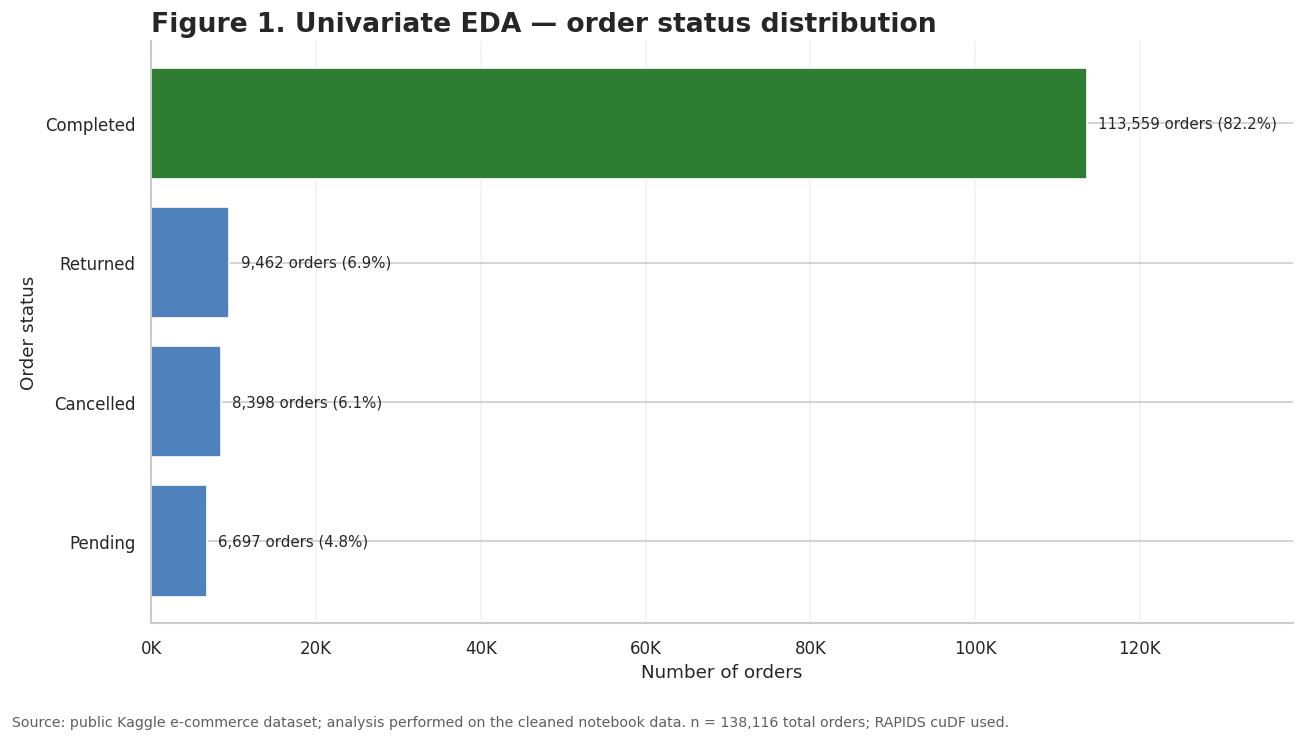

In [107]:
# FIGURE 1 — UNIVARIATE: ORDER STATUS
status_plot = gpu_summary(df_gpu, ["order_status"], {"order_id": "count"})
status_plot = status_plot.rename(columns={"order_id": "Orders"})
status_plot["Share"] = status_plot["Orders"] / status_plot["Orders"].sum() * 100
status_plot = status_plot.sort_values("Orders")
colors = [COLORS["positive"] if x == "Completed" else COLORS["secondary"]
          for x in status_plot["order_status"]]

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(status_plot["order_status"], status_plot["Orders"], color=colors)
labels = [f"{n:,.0f} orders ({p:.1f}%)"
          for n, p in zip(status_plot["Orders"], status_plot["Share"])]
annotate_bar_values(ax, bars, status_plot["Orders"], labels, horizontal=True)
ax.set_title("Figure 1. Univariate EDA — order status distribution",
             loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Order status")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
ax.set_xlim(0, status_plot["Orders"].max() * 1.22)
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
add_source_note(fig, f"n = {len(df_clean):,} total orders; RAPIDS cuDF used.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_01_order_status_univariate.png", dpi=300, bbox_inches="tight")
plt.show()


Most orders are completed, accounting for 82.2% of the dataset. The remaining orders are returned, cancelled, or pending. These categories represent different outcomes and should be separated when analyzing completed-order sales and delivery performance

this EDA helps decide which orders belong in our training data. We would train using completed orders with known delivery outcomes. Cancelled and pending orders should not be labeled “on time,” because they do not provide an observed completed delivery.

EDA Question 2 — How do completed order volume and net sales change over time?


Time is compared with two business outcomes: completed orders and net sales.

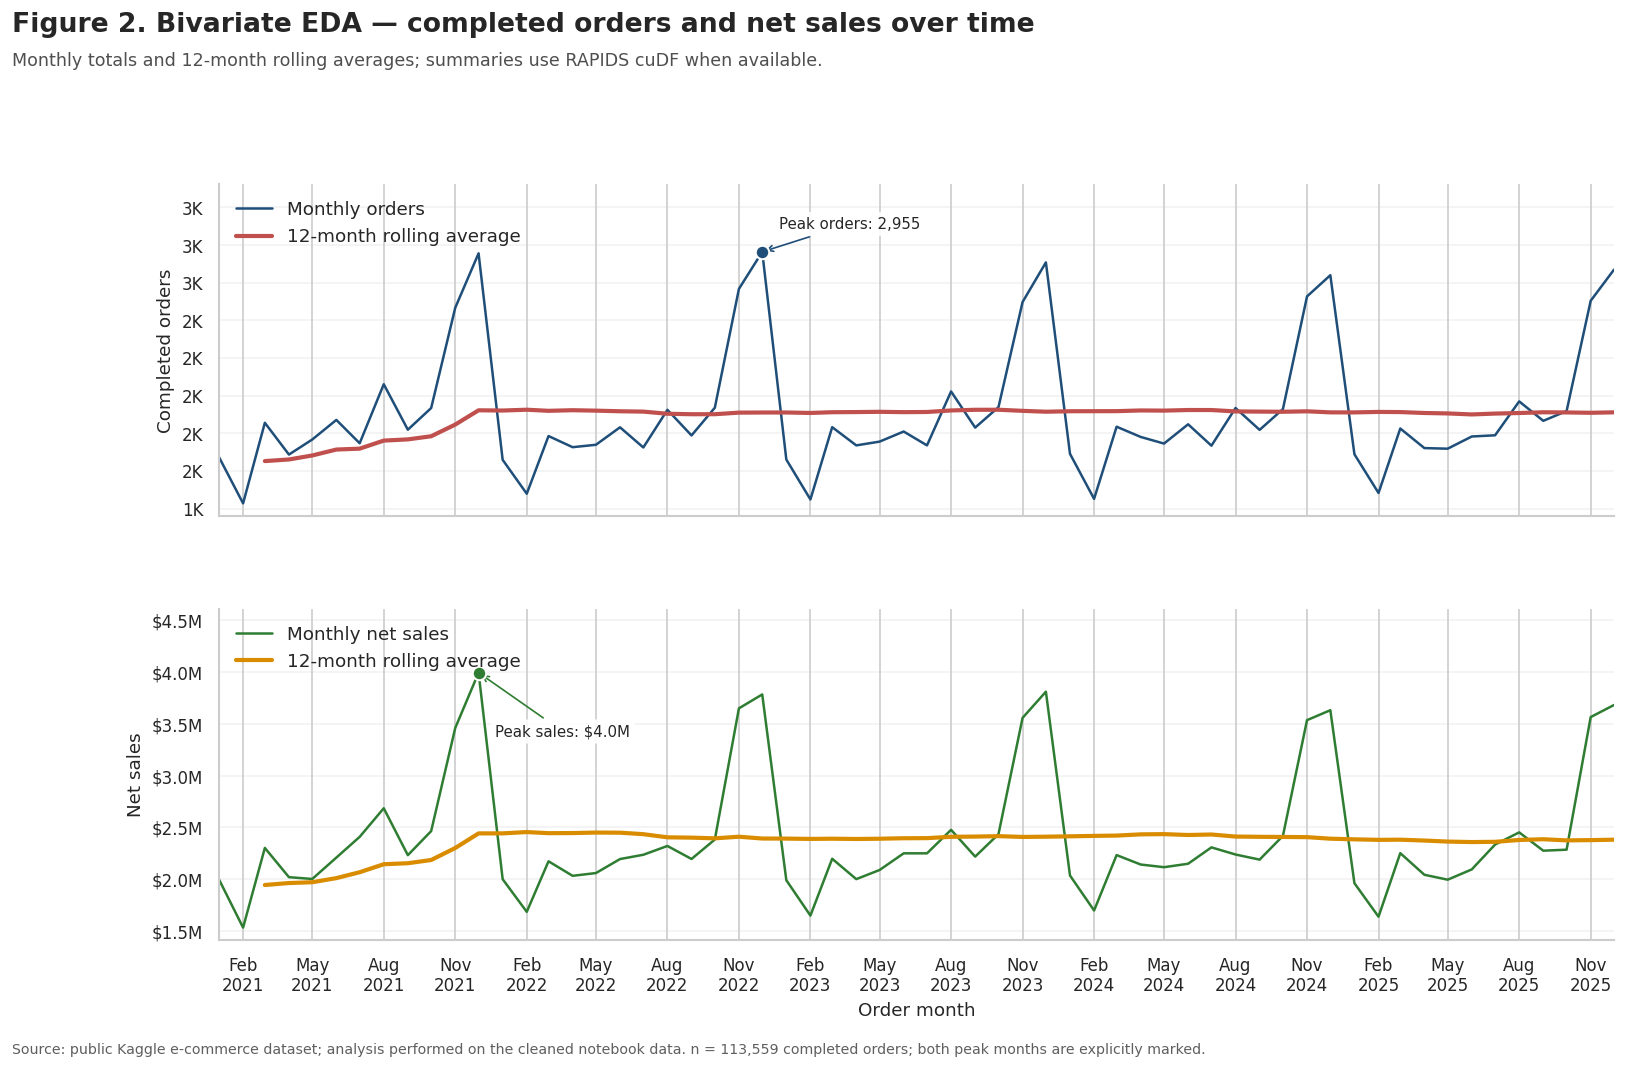

In [108]:
# FIGURE 2 — BIVARIATE: MONTHLY ORDERS AND NET SALES
monthly_plot = gpu_summary(
    completed_gpu,
    ["order_year", "order_month"],
    {"order_id": "count", "net_sales": "sum"}
).rename(columns={"order_id": "Orders", "net_sales": "Net_Sales"})
monthly_plot = monthly_plot.sort_values(["order_year", "order_month"]).copy()
monthly_plot["order_month_period"] = pd.PeriodIndex(
    pd.to_datetime(dict(
        year=monthly_plot["order_year"].astype(int),
        month=monthly_plot["order_month"].astype(int),
        day=1
    )), freq="M"
)
monthly_plot["Orders_12M_MA"] = monthly_plot["Orders"].rolling(12, min_periods=3).mean()
monthly_plot["Net_Sales_12M_MA"] = monthly_plot["Net_Sales"].rolling(12, min_periods=3).mean()
dates = monthly_plot["order_month_period"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle("Figure 2. Bivariate EDA — completed orders and net sales over time",
             x=0.01, y=0.98, ha="left", fontsize=16, fontweight="bold")
fig.text(0.01, 0.93,
         "Monthly totals and 12-month rolling averages; summaries use RAPIDS cuDF when available.",
         fontsize=10.5, color="#4f4f4f")
axes[0].plot(dates, monthly_plot["Orders"], color=COLORS["primary"], label="Monthly orders")
axes[0].plot(dates, monthly_plot["Orders_12M_MA"], color=COLORS["accent"],
             linewidth=2.5, label="12-month rolling average")
axes[0].set_ylabel("Completed orders")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
axes[0].legend(loc="upper left")
axes[0].grid(axis="y", alpha=0.25)
axes[1].plot(dates, monthly_plot["Net_Sales"], color=COLORS["positive"], label="Monthly net sales")
axes[1].plot(dates, monthly_plot["Net_Sales_12M_MA"], color=COLORS["highlight"],
             linewidth=2.5, label="12-month rolling average")
axes[1].set_ylabel("Net sales")
axes[1].set_xlabel("Order month")
axes[1].yaxis.set_major_formatter(FuncFormatter(money_fmt))
axes[1].legend(loc="upper left")
axes[1].grid(axis="y", alpha=0.25)
for ax in axes:
    sns.despine(ax=ax)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[1].set_xlim(dates.min(), dates.max())
peak_orders = monthly_plot.loc[monthly_plot["Orders"].idxmax()]
peak_sales = monthly_plot.loc[monthly_plot["Net_Sales"].idxmax()]

axes[0].scatter(
    peak_orders["order_month_period"].to_timestamp(),
    peak_orders["Orders"],
    color=COLORS["primary"], edgecolor="white", linewidth=1.2, s=65, zorder=5
)
axes[0].annotate(
    f"Peak orders: {peak_orders['Orders']:,.0f}",
    xy=(peak_orders["order_month_period"].to_timestamp(), peak_orders["Orders"]),
    xytext=(10, 14), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["primary"]},
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85},
    fontsize=9, clip_on=False
)
axes[1].scatter(
    peak_sales["order_month_period"].to_timestamp(),
    peak_sales["Net_Sales"],
    color=COLORS["positive"], edgecolor="white", linewidth=1.2, s=65, zorder=5
)
axes[1].annotate(
    f"Peak sales: {money_fmt(peak_sales['Net_Sales'], 0)}",
    xy=(peak_sales["order_month_period"].to_timestamp(), peak_sales["Net_Sales"]),
    xytext=(10, -38), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["positive"]},
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85},
    fontsize=9, clip_on=False
)
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.12)
axes[1].set_ylim(top=axes[1].get_ylim()[1] * 1.12)
add_source_note(fig, f"n = {len(completed):,} completed orders; both peak months are explicitly marked.")
# Explicit spacing keeps the top graph visible.
fig.subplots_adjust(top=0.82, bottom=0.12, hspace=0.28)
fig.savefig(FIG_DIR / "fig_02_monthly_orders_sales_bivariate.png", dpi=300, bbox_inches="tight")
plt.show()



The graph shows recurring increases in completed orders and raw net sales around November and December, followed by lower activity early in the next year. The highest completed-order count is 2,955 in December 2022. The highest raw monthly sales total is approximately 4.0 million in December 2021.


The recurring peaks support exploring monthly order-demand forecasting. For our delivery-delay model, month and other calendar features are reasonable inputs to test

Question 3 — Which sales channels contribute the most net sales and profit?

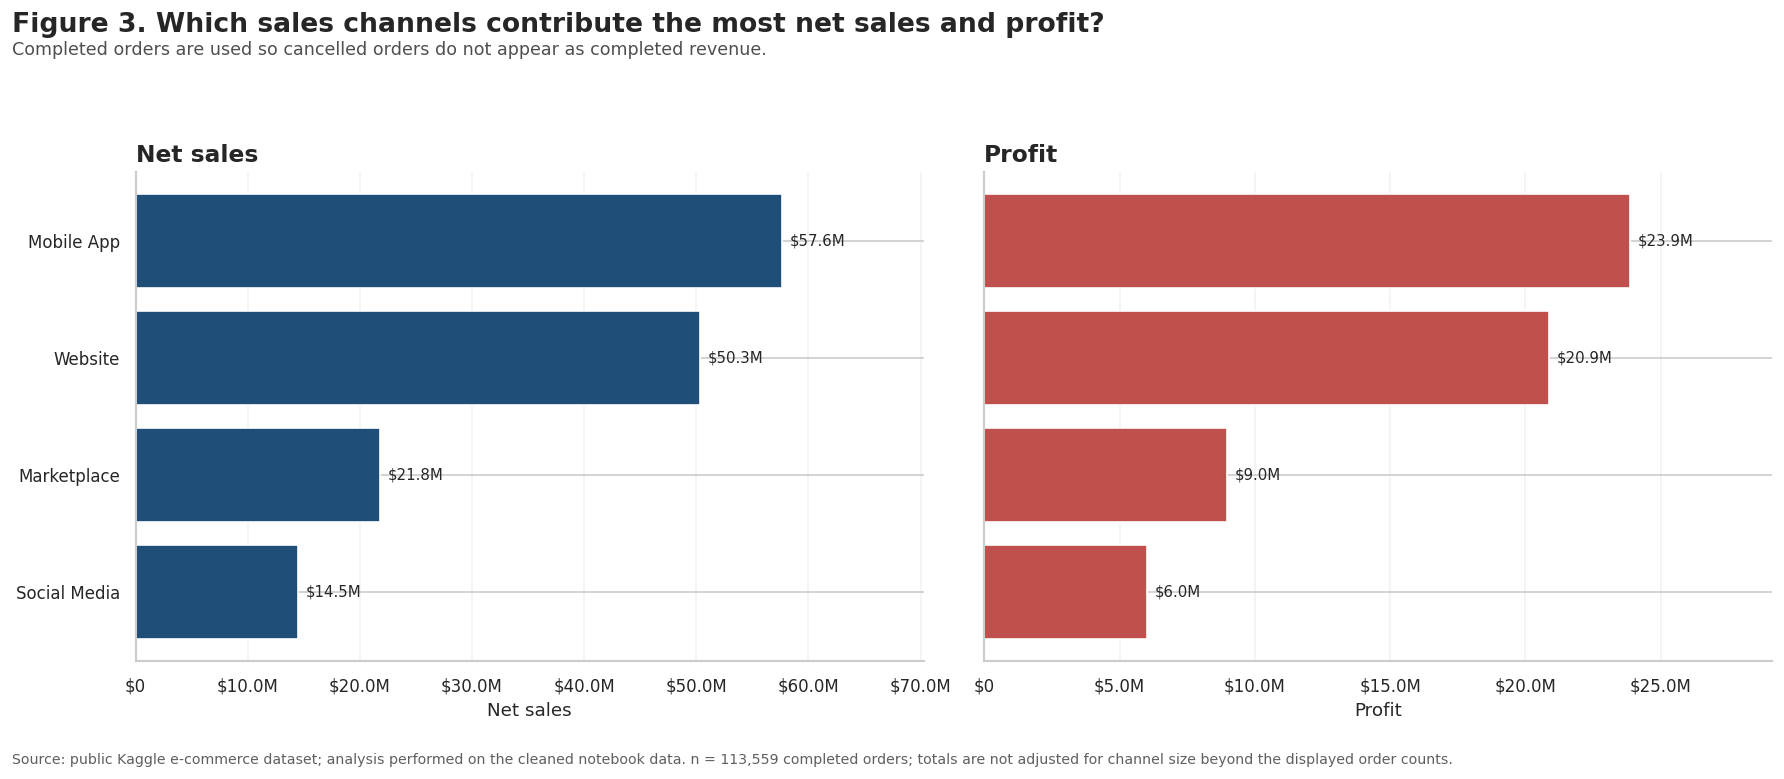

In [109]:
# FIGURE 3 — Bivariate CHANNEL SALES AND PROFIT
channel_plot = channel_summary.sort_values("Net_Sales").copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
fig.suptitle(
    "Figure 3. Which sales channels contribute the most net sales and profit?",
    x=0.01,
    ha="left",
    fontsize=16,
    fontweight="bold",
)
fig.text(0.01, 0.925, "Completed orders are used so cancelled orders do not appear as completed revenue.", fontsize=10.5, color="#4f4f4f")

sales_bars = axes[0].barh(channel_plot["sales_channel"], channel_plot["Net_Sales"], color=COLORS["primary"])
sales_labels = [money_fmt(v, 0) for v in channel_plot["Net_Sales"]]
annotate_bar_values(axes[0], sales_bars, channel_plot["Net_Sales"], sales_labels, horizontal=True)
axes[0].set_title("Net sales", loc="left", fontweight="bold")
axes[0].set_xlabel("Net sales")
axes[0].xaxis.set_major_formatter(FuncFormatter(money_fmt))

profit_bars = axes[1].barh(channel_plot["sales_channel"], channel_plot["Profit"], color=COLORS["accent"])
profit_labels = [money_fmt(v, 0) for v in channel_plot["Profit"]]
annotate_bar_values(axes[1], profit_bars, channel_plot["Profit"], profit_labels, horizontal=True)
axes[1].set_title("Profit", loc="left", fontweight="bold")
axes[1].set_xlabel("Profit")
axes[1].xaxis.set_major_formatter(FuncFormatter(money_fmt))

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    sns.despine(ax=ax)

axes[0].set_xlim(0, channel_plot["Net_Sales"].max() * 1.22)
axes[1].set_xlim(0, channel_plot["Profit"].max() * 1.22)
add_source_note(fig, f"n = {len(completed):,} completed orders; totals are not adjusted for channel size beyond the displayed order counts.")
fig.tight_layout(rect=[0, 0.045, 1, 0.90])
fig.savefig(FIG_DIR / "fig_03_channel_sales_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Mobile App ranks first for both sales and profit, followed by Website, Marketplace, and Social Media. The ranking is consistent across both panels.
These are total amounts. The graph does not establish which channel earns the highest profit per order.


this graph describes business contribution; we must test separately whether channel helps predict delivery outcomes.

Question 4 — Research question: Which shipping method has the highest delayed-delivery rate?


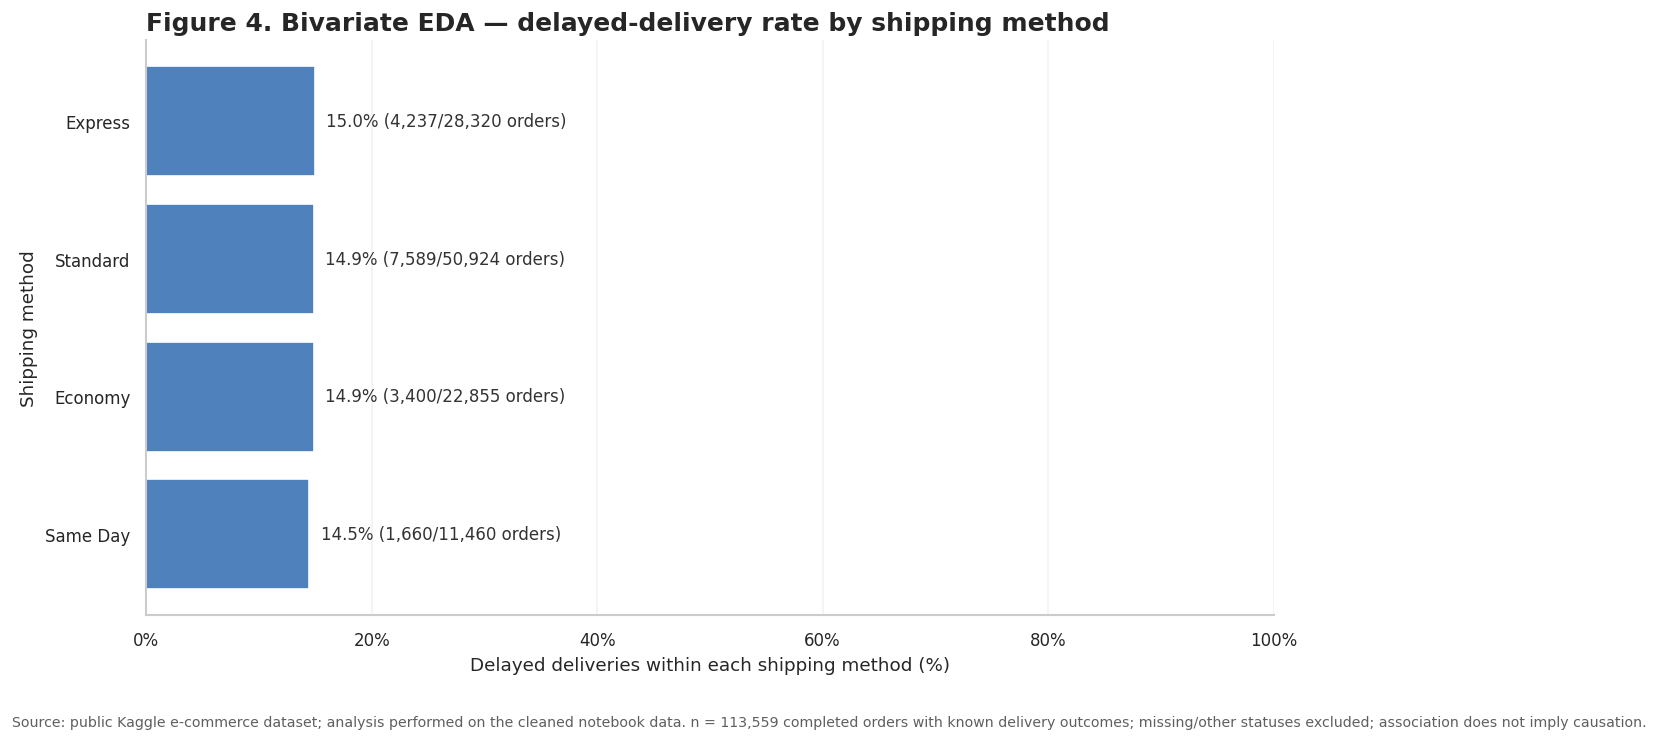

,shipping_method,Orders,Delayed_Orders,Delayed_Percent
3,Same Day,11460,1660,14.49
1,Economy,22855,3400,14.88
0,Standard,50924,7589,14.90
2,Express,28320,4237,14.96


In [110]:
# FIGURE 4 — BIVARIATE: SHIPPING METHOD AND DELIVERY DELAY
shipping_data = completed_gpu.dropna(subset=['shipping_method', 'delivery_status']).copy()
shipping_data = shipping_data[
    shipping_data['delivery_status'].isin(['On Time', 'Early', 'Delayed'])
].copy()
shipping_data['Delayed_Flag'] = (shipping_data['delivery_status'] == 'Delayed').astype('int8')
shipping_plot = gpu_summary(
    shipping_data, ['shipping_method'],
    {'Delayed_Flag': 'sum', 'order_id': 'count'}
).rename(columns={'Delayed_Flag': 'Delayed_Orders', 'order_id': 'Orders'})
shipping_plot['Delayed_Percent'] = shipping_plot['Delayed_Orders'] / shipping_plot['Orders'] * 100
shipping_plot = shipping_plot.sort_values('Delayed_Percent')
if shipping_plot.empty:
    raise ValueError('No completed orders have a recognized delivery status and shipping method.')

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(shipping_plot['shipping_method'], shipping_plot['Delayed_Percent'],
              color=COLORS['secondary'], edgecolor='white')
for bar, (_, row) in zip(bars, shipping_plot.iterrows()):
    rate = float(row['Delayed_Percent'])
    label = f"{rate:.1f}% ({int(row['Delayed_Orders']):,}/{int(row['Orders']):,} orders)"
    ax.text(rate - 1 if rate >= 70 else rate + 1,
            bar.get_y() + bar.get_height() / 2, label,
            ha='right' if rate >= 70 else 'left', va='center',
            color='white' if rate >= 70 else '#333333', fontsize=10)
ax.set_title('Figure 4. Bivariate EDA — delayed-delivery rate by shipping method',
             loc='left', fontsize=15, fontweight='bold')
ax.set_xlabel('Delayed deliveries within each shipping method (%)')
ax.set_ylabel('Shipping method')
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
sns.despine(ax=ax)
add_source_note(
    fig,
    f'n = {int(shipping_plot["Orders"].sum()):,} completed orders with known delivery outcomes; '
    'missing/other statuses excluded; association does not imply causation.'
)
fig.tight_layout(rect=[0, 0.055, 1, 0.96])
fig.savefig(FIG_DIR / 'fig_04_shipping_delay_bivariate.png', dpi=300, bbox_inches='tight')
plt.show()
display(shipping_plot[['shipping_method', 'Orders', 'Delayed_Orders', 'Delayed_Percent']])

Express has the highest observed delay rate, while Same Day has the lowest. However, all four rates are close to 15%. The difference between the highest and lowest is only approximately 0.48 percentage points.
Therefore, the graph shows little separation between shipping methods. It does not establish that one method is substantially more reliable.

Shipping method is a candidate input, but it may have limited predictive value by itself. We should test whether it becomes useful alongside calendar, location, warehouse, and other information available before delivery.

Question: Does delayed-delivery risk vary jointly by sales channel and customer segment?

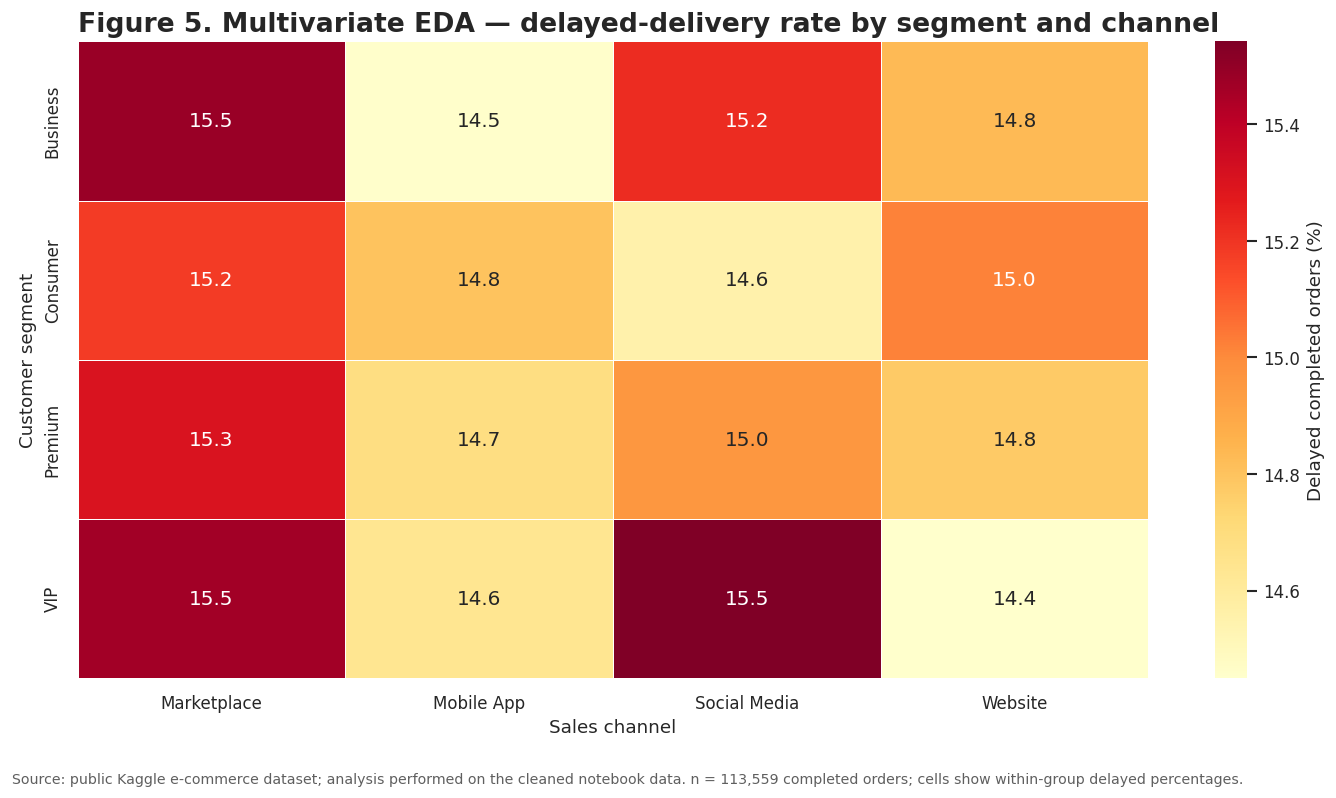

In [111]:
# FIGURE 5 — MULTIVARIATE: DELAY RATE BY CHANNEL AND CUSTOMER SEGMENT
completed_gpu["Delayed_Flag"] = (
    completed_gpu["delivery_status"] == "Delayed"
).astype("int8")
delay_plot = gpu_summary(
    completed_gpu,
    ["customer_segment", "sales_channel"],
    {"Delayed_Flag": "mean", "order_id": "count"}
).rename(columns={"Delayed_Flag": "Delayed_Rate", "order_id": "Orders"})
delay_plot["Delayed_Percent"] = delay_plot["Delayed_Rate"] * 100
delay_table = delay_plot.pivot(index="customer_segment",
                               columns="sales_channel",
                               values="Delayed_Percent")
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(delay_table, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5,
            cbar_kws={"label": "Delayed completed orders (%)"}, ax=ax)
ax.set_title("Figure 5. Multivariate EDA — delayed-delivery rate by segment and channel",
             loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Sales channel")
ax.set_ylabel("Customer segment")
add_source_note(fig, f"n = {len(completed):,} completed orders; cells show within-group delayed percentages.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_05_delay_rate_heatmap_multivariate.png", dpi=300, bbox_inches="tight")
plt.show()


The displayed delay rates range from approximately 14.4% to 15.5%. VIP customers ordering through Website have the lowest displayed rate, at 14.4%. Business–Marketplace, VIP–Marketplace, and VIP–Social Media are among the highest displayed combinations, at 15.5%.

EDA Question 6: Are customer ratings different for on-time and delayed completed orders?

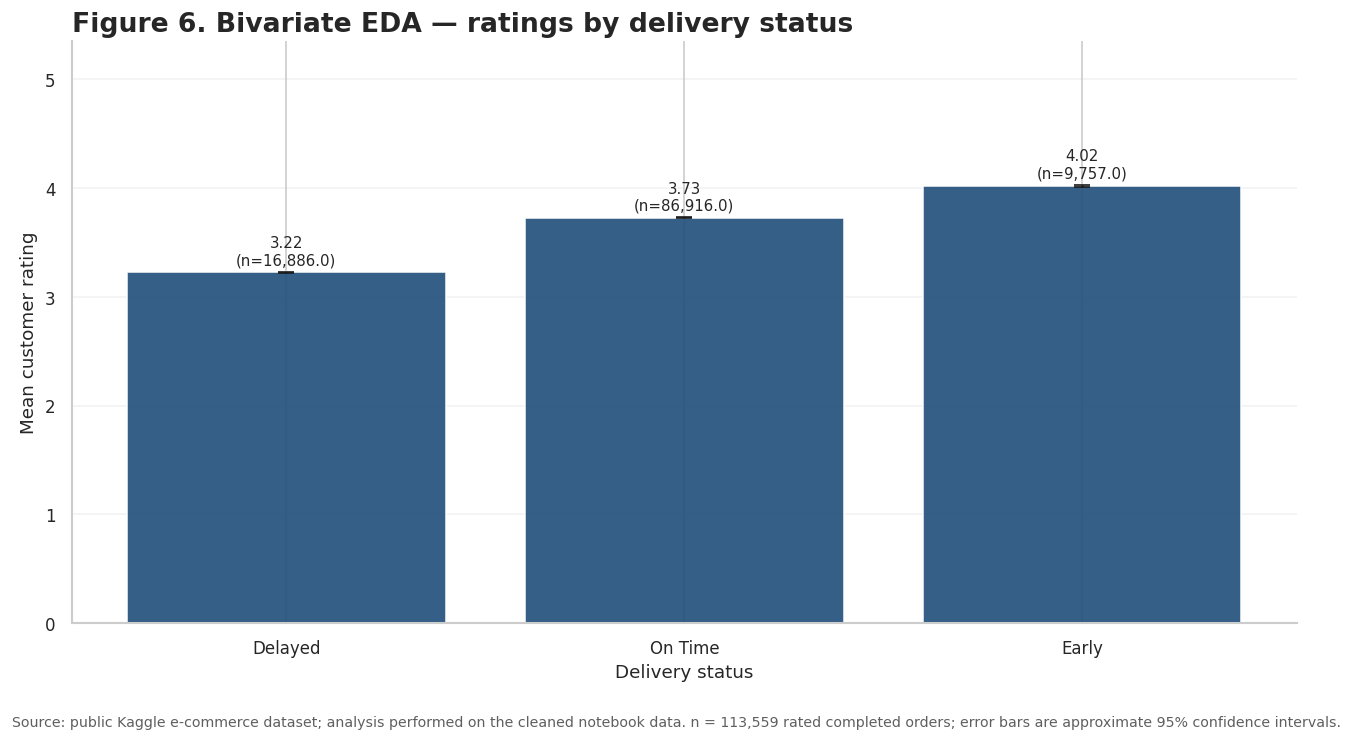

In [112]:
# FIGURE 6 — BIVARIATE: DELIVERY STATUS AND CUSTOMER RATING
rating_data = completed.dropna(
    subset=["delivery_status", "customer_rating"]
)
rating_stats = (
    rating_data.groupby("delivery_status")
    .agg(
        Average_Rating=("customer_rating", "mean"),
        Standard_Deviation=("customer_rating", "std"),
        N=("customer_rating", "count"),
    )
    .sort_values("Average_Rating")
)
rating_stats["CI95"] = (
    1.96
    * rating_stats["Standard_Deviation"].fillna(0)
    / np.sqrt(rating_stats["N"])
)

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.bar(
    rating_stats.index,
    rating_stats["Average_Rating"],
    yerr=rating_stats["CI95"],
    capsize=5,
    color=COLORS["primary"],
    alpha=0.9,
)
for bar, (_, row) in zip(bars, rating_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["CI95"] + 0.04,
        f"{row['Average_Rating']:.2f}\n(n={row['N']:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_title(
    "Figure 6. Bivariate EDA — ratings by delivery status",
    loc="left", fontsize=16, fontweight="bold"
)
ax.set_xlabel("Delivery status")
ax.set_ylabel("Mean customer rating")
ax.set_ylim(0, 5.35)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
add_source_note(
    fig,
    f"n = {len(rating_data):,} rated completed orders; error bars are approximate 95% confidence intervals."
)
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_06_rating_by_delivery_bivariate.png",
            dpi=300, bbox_inches="tight")
plt.show()


Delayed deliveries have the lowest average customer rating. On-time deliveries score approximately 0.51 points higher, while early deliveries score approximately 0.80 points higher than delayed deliveries.
This shows an association between delivery outcomes and customer satisfaction. It does not prove that delivery timing alone caused the rating differences.

This is the clearest business reason to investigate delay prediction: identifying orders at risk could help the business intervene before customers experience delays.
Customer ratings must be excluded from a model that predicts delays before delivery, because those ratings are collected afterward. Using information unavailable at prediction time would create data leakage.

In [ ]:
# CPU versus GPU aggregation benchmark
import time

benchmark_group_cols = ["sales_channel", "customer_segment"]
benchmark_aggs = {"net_sales": "sum", "profit": "sum", "order_id": "count"}

cpu_start = time.perf_counter()
cpu_benchmark = (
    completed.groupby(benchmark_group_cols, as_index=False)
    .agg(
        Net_Sales=("net_sales", "sum"),
        Profit=("profit", "sum"),
        Orders=("order_id", "count"),
    )
)
cpu_seconds = time.perf_counter() - cpu_start

if RAPIDS_AVAILABLE:
    gpu_start = time.perf_counter()
    gpu_benchmark = gpu_summary(
        completed_gpu,
        benchmark_group_cols,
        benchmark_aggs
    ).rename(columns={
        "net_sales": "Net_Sales",
        "profit": "Profit",
        "order_id": "Orders",
    })
    gpu_seconds = time.perf_counter() - gpu_start
    same_result = (
        cpu_benchmark.sort_values(benchmark_group_cols)
        .reset_index(drop=True)
        .round(6)
        .equals(
            gpu_benchmark[benchmark_group_cols + ["Net_Sales", "Profit", "Orders"]]
            .sort_values(benchmark_group_cols)
            .reset_index(drop=True)
            .round(6)
        )
    )
else:
    gpu_seconds = np.nan
    same_result = "RAPIDS unavailable on this machine"

cpu_gpu_comparison = pd.DataFrame({
    "Implementation": ["CPU / pandas", "GPU / RAPIDS cuDF"],
    "Runtime_seconds": [cpu_seconds, gpu_seconds],
    "Results_match": [True, same_result],
})
display(cpu_gpu_comparison)

if RAPIDS_AVAILABLE and gpu_seconds > 0:
    print(f"End-to-end CPU/GPU speed ratio: {cpu_seconds / gpu_seconds:.2f}x")
else:
    print("GPU Runtime not selected.")


,Implementation,Runtime_seconds,Results_match
0,CPU / pandas,0.03,True
1,GPU / RAPIDS cuDF,0.00,True


End-to-end CPU/GPU speed ratio: 7.77x


Our proposed ML task is to predict whether an order will be delayed before delivery.

Training population	Completed orders with recognized delivery outcomes

inputs	Shipping method, channel, customer segment, month, weekday, and other information available before delivery

models	Logistic regression